# DistilBERT Fine-Tuning for Ticket Type Classification

## Objective

The objective of this notebook is to fine-tune a pre-trained DistilBERT model for multi-class Ticket Type classification.

The model is trained using the combined Ticket Subject and Ticket Description text.

### Workflow

1. Load processed dataset
2. Create combined text
3. Encode target labels
4. Train/Validation/Test split
5. DistilBERT tokenization
6. Hugging Face Dataset creation
7. DistilBERT fine-tuning
8. AdamW optimization with learning rate warmup
9. Model evaluation
10. MLflow logging
11. Final comparison with previous models

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from datasets import Dataset

import torch
import accelerate
import matplotlib.pyplot as plt
import seaborn as sns

## Load Processed Dataset

The processed ticket subject and ticket description are loaded and combined to create the input text used for DistilBERT fine-tuning.

In [2]:
df = pd.read_parquet(
    "../data/processed/text_processed.parquet"
)

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,...,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,clean_description,clean_ticket_subject,processed_description,processed_ticket_subject,combined_text
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,Critical,Social media,2023-06-01 12:15:36,NaT,NaN,i am having an issue with the please assist yo...,product setup,issue please assist billing zip code 71701 app...,product setup,product setup issue please assist billing zip ...
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,Critical,Chat,2023-06-01 16:45:38,NaT,NaN,i am having an issue with the please assist if...,peripheral compatibility,issue please assist need change existing produ...,peripheral compatibility,peripheral compatibility issue please assist n...
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,i am facing a problem with my the is not turni...,network problem,facing problem turning working fine yesterday ...,network problem,network problem facing problem turning working...
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,i am having an issue with the please assist if...,account access,issue please assist problem interested would l...,account access,account access issue please assist problem int...
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,i am having an issue with the please assist no...,data loss,issue please assist note seller responsible da...,data loss,data loss issue please assist note seller resp...


In [4]:
# check columns
df.columns.tolist()

['Ticket ID',
 'Customer Name',
 'Customer Email',
 'Customer Age',
 'Customer Gender',
 'Product Purchased',
 'Date of Purchase',
 'Ticket Type',
 'Ticket Subject',
 'Ticket Description',
 'Ticket Status',
 'Resolution',
 'Ticket Priority',
 'Ticket Channel',
 'First Response Time',
 'Time to Resolution',
 'Customer Satisfaction Rating',
 'clean_description',
 'clean_ticket_subject',
 'processed_description',
 'processed_ticket_subject',
 'combined_text']

In [3]:
# Select feature and target
X = df["combined_text"]

y = df["Ticket Type"]

print(X.shape)
print(y.shape)

(8469,)
(8469,)


In [6]:
print(X.isnull().sum())
print(y.isnull().sum())

0
0


## Label Encoding

The target variable is converted into numerical labels to enable model training.

In [4]:
# Encode target
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Billing inquiry' 'Cancellation request' 'Product inquiry'
 'Refund request' 'Technical issue']


In [8]:
# Save this encoder
import joblib
from pathlib import Path

Path("../models/distilbert").mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    label_encoder,
    "../models/distilbert/label_encoder.pkl"
)

['../models/distilbert/label_encoder.pkl']

## Train, Validation, and Test Split

The dataset is divided into training, validation, and testing subsets using stratified sampling to preserve class distributions.

In [5]:
# Train / Validation / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 5928
Validation: 1270
Test: 1271


In [9]:
# Verify class distribution
print(pd.Series(y_train).value_counts(normalize=True))

3    0.206815
4    0.206309
1    0.200067
2    0.193826
0    0.192982
Name: proportion, dtype: float64


## DistilBERT Tokenization

The DistilBERT tokenizer converts raw text into token IDs and attention masks that can be processed by the transformer model.

The pre-trained tokenizer `distilbert-base-uncased` is used.

In [10]:
# Load Tokenizer
MODEL_NAME = "distilbert-base-uncased"

tokenizer = DistilBertTokenizerFast.from_pretrained(
    MODEL_NAME
)

tokenizer

DistilBertTokenizerFast(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [11]:
# Check sequence Length
text_lengths = X_train.astype(str).apply(
    lambda x: len(tokenizer.tokenize(x))
)

print("Max Length:", text_lengths.max())
print("Average Length:", text_lengths.mean())
print("95th Percentile:", np.percentile(text_lengths, 95))

Max Length: 62
Average Length: 25.061234817813766
95th Percentile: 33.0


In [12]:
# Set max length (Based on your earlier text statistics)
MAX_LENGTH = 64

In [13]:
# create a tokenizer function
def tokenize_function(examples):
    
    return tokenizer(
        examples["text"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH
    )

In [14]:
# Create Dataframes
train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

val_df = pd.DataFrame({
    "text": X_val,
    "label": y_val
})

test_df = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

In [15]:
# Save test dataset
test_df.to_parquet("../data/distilbert_test_data/test_data.parquet")

In [16]:
# Convert dataframes to huggingface datasets
train_dataset = Dataset.from_pandas(
    train_df,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df,
    preserve_index=False
)

In [17]:
# Apply tokenization
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/5928 [00:00<?, ? examples/s]

Map:   0%|          | 0/1270 [00:00<?, ? examples/s]

Map:   0%|          | 0/1271 [00:00<?, ? examples/s]

In [18]:
# Create data collator
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [19]:
# verify datasets
print(train_dataset)

print(train_dataset[0])

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 5928
})
{'text': 'battery life issue please assist 5 382013 13835 pf4njv0 0x9d09a332880 0x9d noticed peculiar error message popping screen say mean', 'label': 4, 'input_ids': [101, 6046, 2166, 3277, 3531, 6509, 1019, 4229, 11387, 17134, 15028, 19481, 1052, 2546, 2549, 2078, 3501, 2615, 2692, 1014, 2595, 2683, 2094, 2692, 2683, 2050, 22394, 22407, 17914, 1014, 2595, 2683, 2094, 4384, 14099, 7561, 4471, 20095, 3898, 2360, 2812, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


## DistilBERT Model Initialization

A pre-trained DistilBERT model is fine-tuned for multi-class Ticket Type classification.

The classification head is automatically adapted to predict the five ticket categories.

In [20]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\abdul\AppData\Local\Programs\Python\Python311\python.exe
3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


In [21]:
import torch
print(torch.__version__)

2.12.0+cpu


In [22]:
import transformers
print(transformers.__version__)

4.55.4


In [23]:
from transformers import DistilBertTokenizerFast
print("Tokenizer OK")

Tokenizer OK


In [24]:
from transformers import DistilBertForSequenceClassification
print("Model Class OK")

Model Class OK


In [25]:
from transformers.utils import is_torch_available

print("Torch Available:", is_torch_available())

import torch
print("Torch Version:", torch.__version__)

Torch Available: True
Torch Version: 2.12.0+cpu


In [26]:
import transformers

print(transformers.__version__)

4.55.4


In [27]:
# Load DistilBERT Model
NUM_CLASSES = len(label_encoder.classes_)

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=NUM_CLASSES
)

print("Model Loaded Successfully")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Loaded Successfully


In [28]:
# Create a metrics function

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    return {
        "accuracy": accuracy,
        "f1_macro": f1
    }

## Training Configuration

DistilBERT is fine-tuned using:

- AdamW optimizer
- Learning rate warmup
- Weight decay regularization
- Evaluation on validation data
- Best model selection based on F1-Macro

In [29]:
import accelerate
print(accelerate.__version__)

1.13.0


In [30]:
import accelerate
print(accelerate.__version__)
print(accelerate.__file__)

1.13.0
c:\Users\abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\accelerate\__init__.py


In [31]:
from transformers.utils import (
    is_torch_available,
    is_accelerate_available
)

print("Torch:", is_torch_available())
print("Accelerate:", is_accelerate_available())

Torch: True
Accelerate: True


In [32]:
# Training arguments
training_args = TrainingArguments(
    output_dir="../models/distilbert/checkpoints",

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",

    greater_is_better=True,

    report_to="none"
)

In [33]:
# Trainer
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    tokenizer=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

C:\Users\abdul\AppData\Local\Temp\ipykernel_17632\3261271701.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


## Fine-Tuning DistilBERT

The model is fine-tuned on the training dataset and evaluated on the validation dataset after each epoch.

In [34]:
# Train
trainer.train()

c:\Users\abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.612500,1.609488,0.207087,0.068624
2,1.610900,1.609019,0.192126,0.143848
3,1.602800,1.610941,0.203150,0.173376


c:\Users\abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=2223, training_loss=1.6087427383814104, metrics={'train_runtime': 1490.6215, 'train_samples_per_second': 11.931, 'train_steps_per_second': 1.491, 'total_flos': 155740317321600.0, 'train_loss': 1.6087427383814104, 'epoch': 3.0})

In [35]:
# Evaluate
trainer.evaluate()

c:\Users\abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 1.6109412908554077,
 'eval_accuracy': 0.2031496062992126,
 'eval_f1_macro': 0.1733759236254128,
 'eval_runtime': 24.7072,
 'eval_samples_per_second': 51.402,
 'eval_steps_per_second': 6.435,
 'epoch': 3.0}

In [40]:
# Test evaluation
test_results = trainer.predict(test_dataset)

print(test_results.metrics)

c:\Users\abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'test_loss': 1.6121162176132202, 'test_accuracy': 0.22580645161290322, 'test_f1_macro': 0.19145806309198432, 'test_runtime': 24.2377, 'test_samples_per_second': 52.439, 'test_steps_per_second': 6.56}


In [41]:
# Predictions
pred_labels = np.argmax(test_results.predictions, axis=1)

true_labels = test_results.label_ids

In [47]:
# Classification Report
from sklearn.metrics import classification_report


distilbert_report = classification_report(
    true_labels,
    pred_labels,
    target_names=label_encoder.classes_,
    output_dict=True
)


distilbert_report_df = pd.DataFrame(distilbert_report).transpose()

distilbert_report_df

,precision,recall,f1-score,support
Billing inquiry,0.188235,0.065306,0.096970,245.000000
Cancellation request,0.200000,0.082353,0.116667,255.000000
Product inquiry,0.233645,0.101626,0.141643,246.000000
Refund request,0.215470,0.444867,0.290323,263.000000
Technical issue,0.250580,0.412214,0.311688,262.000000
accuracy,0.225806,0.225806,0.225806,0.225806
macro avg,0.217586,0.221273,0.191458,1271.000000
weighted avg,0.217872,0.225806,0.193839,1271.000000


In [48]:
# Save report
import os

os.makedirs("../model_results/distilbert", exist_ok=True)

distilbert_report_df.to_csv(
    "../model_results/distilbert/classification_report.csv"
)

print("Classification report saved")

Classification report saved


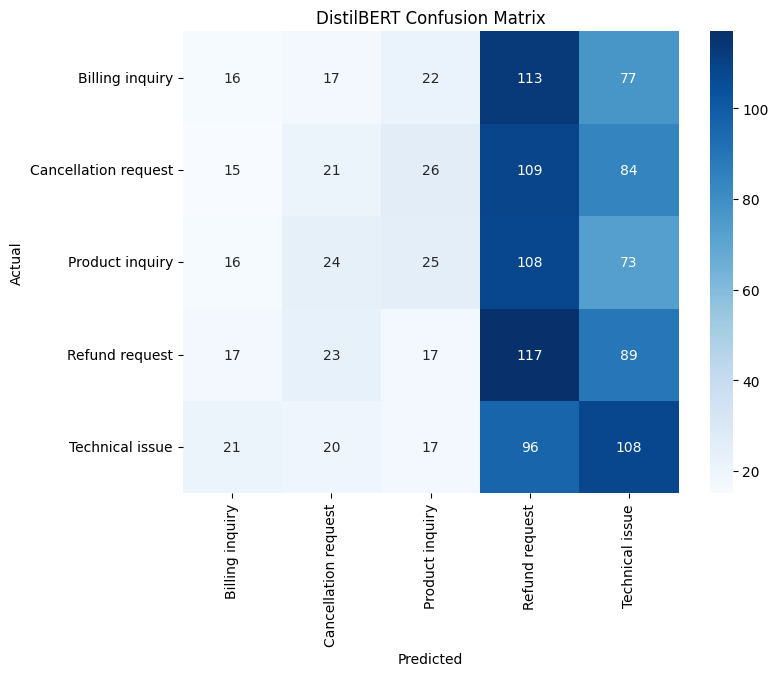

In [53]:
# Confusion Matrix

cm = confusion_matrix(true_labels, pred_labels)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")

plt.show()

In [54]:
# Save confusion matrix
cm_df.to_csv(
    "../model_results/distilbert/confusion_matrix.csv"
)

print("Confusion matrix saved")

Confusion matrix saved


In [44]:
# Save Model
model_path = "../models/distilbert"

trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print("Saved")

Saved


In [55]:
# save metrics
from sklearn.metrics import accuracy_score, f1_score

distilbert_metrics = pd.DataFrame({
    "Model": ["DistilBERT"],
    "Accuracy": [
        accuracy_score(true_labels, pred_labels)
    ],
    "F1_Macro": [
        f1_score(
            true_labels,
            pred_labels,
            average="macro"
        )
    ]
})


distilbert_metrics.to_csv(
    "../model_results/distilbert/distilbert_results.csv",
    index=False
)

distilbert_metrics

,Model,Accuracy,F1_Macro
0,DistilBERT,0.225806,0.191458


In [57]:
# Add to model comparision
model_comparison = pd.read_csv(
    "../model_results/model_comparison_results.csv"
)
model_comparison = pd.concat(
    [
        model_comparison,
        distilbert_metrics
    ],
    ignore_index=True
)


model_comparison.to_csv(
    "../model_results/model_comparison_results.csv",
    index=False
)

model_comparison

,Model,Accuracy,F1_Macro
0,Logistic Regression,0.208700,0.207800
1,XGBoost,0.207900,0.206200
2,Multinomial Naive Bayes,0.207100,0.204500
3,Random Forest,0.200800,0.188600
4,LightGBM,0.188200,0.188100
5,BiLSTM + GloVe,0.201575,0.174215
6,DistilBERT,0.225806,0.191458


# ML Flow 

In [58]:
import dagshub
import mlflow

https://dagshub.com/armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform.git

In [59]:
dagshub.init(
    repo_owner='armaaz.au.stats',
    repo_name='AI-Powered-Customer-Support-Intelligence-Platform',
    mlflow=True
)

Accessing as armaaz.au.stats

Initialized MLflow to track repo "armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform"

Repository armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform initialized!

In [60]:
# Set experiment
mlflow.set_experiment(
    "Distilbert Model"
)

2026/06/13 06:44:29 INFO mlflow.tracking.fluent: Experiment with name 'Distilbert Model' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/9ac20b3169764eb18b0bd339bb33fba0', creation_time=1781313270020, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1781313270020, lifecycle_stage='active', name='Distilbert Model', tags={}, trace_location=None, workspace='default'>

In [61]:
# Log

with mlflow.start_run(run_name="DistilBERT_Ticket_Type"):

    mlflow.log_param(
        "model",
        "distilbert-base-uncased"
    )

    mlflow.log_param(
        "epochs",
        3
    )

    mlflow.log_metric(
        "accuracy",
        accuracy_score(true_labels, pred_labels)
    )

    mlflow.log_metric(
        "f1_macro",
        f1_score(
            true_labels,
            pred_labels,
            average="macro"
        )
    )

    mlflow.log_artifacts(
        "../model_results/distilbert"
    )

print("MLflow logging completed")

🏃 View run DistilBERT_Ticket_Type at: https://dagshub.com/armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform.mlflow/#/experiments/3/runs/0e5825b162214722823a91f0af8ef969
🧪 View experiment at: https://dagshub.com/armaaz.au.stats/AI-Powered-Customer-Support-Intelligence-Platform.mlflow/#/experiments/3
MLflow logging completed
